In [51]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator

In [52]:
load_dotenv()

True

In [53]:
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.7)

In [54]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="feedback on the essay")
    score: int = Field(description="score out of 10", ge=0, le=10)

In [55]:
structured_model = model.with_structured_output(EvaluationSchema)

In [56]:
class EvaluationState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_score: Annotated[list[int], operator.add]
    avg_score: float

In [57]:
def language_feedback(state: EvaluationState):
    prompt = f'Evaluate the language quality of the following essay and provide feedback and a score out of 10:\n\n{state["essay"]}'
    language_feedback = structured_model.invoke(prompt)

    return {"language_feedback": language_feedback.feedback, "individual_score": [language_feedback.score]}

In [58]:
def analysis_feedback(state: EvaluationState):
    prompt = f'Evaluate the depth ofanalysis of the following essay and provide feedback and a score out of 10:\n\n{state["essay"]}'
    analysis_feedback = structured_model.invoke(prompt)

    return {"analysis_feedback": analysis_feedback.feedback, "individual_score": [analysis_feedback.score]}

In [59]:
def clarity_feedback(state: EvaluationState):
    prompt = f'Evaluate the clarity of thought of the following essay and provide feedback and a score out of 10:\n\n{state["essay"]}'
    clarity_feedback = structured_model.invoke(prompt)

    return {"clarity_feedback": clarity_feedback.feedback, "individual_score": [clarity_feedback.score]}

In [60]:
def overall_feedback(state: EvaluationState):
    prompt = f'Based on the following essay and the feedback on language, analysis and clarity, provide overall feedback:\n\nEssay:\n{state["essay"]}\n\nLanguage Feedback:\n{state["language_feedback"]}\n\nAnalysis Feedback:\n{state["analysis_feedback"]}\n\nClarity Feedback:\n{state["clarity_feedback"]}'
    overall_feedback = model.invoke(prompt)

    avg_score = round(sum(state["individual_score"]) / len(state["individual_score"]), 2)

    return {"overall_feedback": overall_feedback, "avg_score": avg_score}

In [61]:
graph = StateGraph(EvaluationState)

graph.add_node("language_feedback", language_feedback)
graph.add_node("analysis_feedback", analysis_feedback)
graph.add_node("clarity_feedback", clarity_feedback)
graph.add_node("overall_feedback", overall_feedback)

graph.add_edge(START, "language_feedback")
graph.add_edge(START, "analysis_feedback")
graph.add_edge(START, "clarity_feedback")
graph.add_edge("language_feedback", "overall_feedback")
graph.add_edge("analysis_feedback", "overall_feedback")
graph.add_edge("clarity_feedback", "overall_feedback")
graph.add_edge("overall_feedback", END)

workflow = graph.compile()

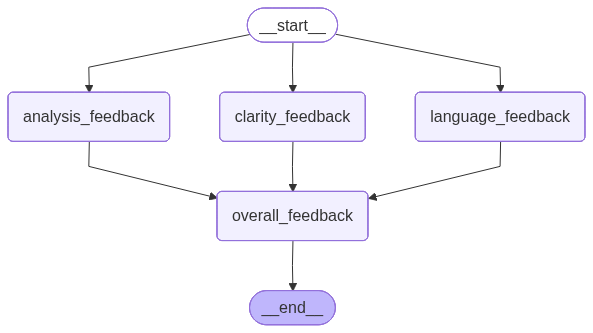

In [62]:
workflow

In [63]:
essay = """
Technology, once considered a mere tool in human hands, has today evolved into a silent architect shaping the contours of modern society. From the way individuals communicate to how economies function and governments operate, technology has permeated every sphere of life. Its influence is subtle yet profound, often invisible yet deeply transformative. While it has unlocked unprecedented opportunities, it has also introduced complex challenges that demand careful reflection.

At the individual level, technology has redefined human interaction. Social media platforms, instant messaging, and virtual communication tools have bridged geographical divides, enabling real-time connectivity across the globe. However, this hyper-connectivity has also led to concerns about declining face-to-face interactions, mental health issues, and the spread of misinformation. The paradox lies in technology’s ability to connect people while simultaneously fostering isolation.

Economically, technology has acted as a catalyst for growth and innovation. The rise of automation, artificial intelligence, and digital platforms has enhanced productivity and created new industries. Startups and digital entrepreneurship have flourished, contributing to job creation and economic dynamism. Yet, the same forces have disrupted traditional employment patterns, leading to job displacement and increasing inequality. The digital divide further exacerbates this disparity, leaving marginalized communities at a disadvantage.

In governance, technology has strengthened transparency and efficiency. E-governance initiatives, digital identity systems, and online service delivery have improved access to public services and reduced corruption. Governments can now leverage data analytics for informed policymaking and better resource allocation. However, concerns regarding data privacy, surveillance, and cybersecurity pose significant ethical dilemmas. The balance between state control and individual freedom becomes increasingly delicate in a technologically driven world.

Education and healthcare have also undergone transformative changes. Online learning platforms and telemedicine have expanded access, particularly in remote areas. Technology has democratized knowledge and improved healthcare delivery. Nevertheless, issues of accessibility, quality, and digital literacy remain critical barriers that must be addressed to ensure inclusive growth.

Environmental sustainability presents another dimension of technological impact. While technology offers solutions such as renewable energy, smart cities, and efficient resource management, it also contributes to environmental degradation through electronic waste and high energy consumption. Thus, technology is both a problem and a solution in the context of sustainability.

Ultimately, technology is not inherently good or bad; its impact depends on how it is designed, deployed, and regulated. Ethical considerations, inclusive policies, and responsible innovation are essential to harness its potential while mitigating risks. Society must adopt a balanced approach that embraces technological advancement without losing sight of human values.

In conclusion, technology, as the silent architect of modern society, continues to shape the present and future in profound ways. Its dual nature demands vigilance, adaptability, and foresight. By aligning technological progress with social, economic, and ethical priorities, humanity can ensure that this powerful force serves as an enabler of collective well-being rather than a source of division.
"""

In [64]:
initial_state = {
    "essay": essay,
}

In [65]:
workflow.invoke(initial_state)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash\nPlease retry in 48.145730095s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-Fre